In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from app_config import DATA_PATH, TARGET_COL
from ml_toolkit import EDAExplorer

In [5]:
eda = EDAExplorer(DATA_PATH, num=1)
df = eda.df.copy()

# Asegurar que el target sea numérico
df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

unique_vals = set(df[TARGET_COL].dropna().unique())

if unique_vals == {-1, 1}:
    df[TARGET_COL] = df[TARGET_COL].map({-1: 0, 1: 1})
elif unique_vals == {0, 1}:
    pass
else:
    raise ValueError(f"Valores inesperados en {TARGET_COL}: {sorted(unique_vals)}")

df[TARGET_COL] = df[TARGET_COL].astype(int)

# Limpiar como en tu flujo
df = df.drop_duplicates().dropna()

print(df.shape)
df.head()

(3203, 29)


,having_ip_address,length_of_url,shortening_services,having_at_symbol,double-slash_redirection,prefix and suffix,sub_domains,ssl_state,domain_registered,favicons,...,on_mouse_over,right_click,popup_windows,domain_age,dns_record,web_traffic,links_pointing,statistical_report,image_text_keyword,result
0,-1,-1,-1,-1,-1,-1,1,1,1,1,...,1,1,1,1,1,1,1,-1,-1,1
1,-1,0,-1,-1,-1,1,0,-1,1,1,...,-1,-1,-1,-1,1,1,-1,-1,1,1
2,-1,-1,-1,-1,-1,-1,-1,-1,1,1,...,-1,-1,-1,-1,1,1,-1,-1,1,1
3,-1,-1,-1,-1,-1,-1,-1,-1,1,1,...,-1,-1,-1,-1,1,0,-1,-1,1,1
4,-1,1,-1,-1,-1,1,1,-1,1,1,...,-1,-1,-1,1,1,-1,-1,-1,-1,1


In [6]:
df_num = df.select_dtypes(include=[np.number]).copy()

print("Columnas numéricas:")
print(df_num.columns.tolist())

Columnas numéricas:
['having_ip_address', 'length_of_url', 'shortening_services', 'having_at_symbol', 'double-slash_redirection', 'prefix and suffix', 'sub_domains', 'ssl_state', 'domain_registered', 'favicons', 'ports', 'https', 'external_objects', 'anchor_tags', 'links_in_tags', 'sfh-domain', 'auto_email', 'abnoramal_url', 'iframe_redirection', 'on_mouse_over', 'right_click', 'popup_windows', 'domain_age', 'dns_record', 'web_traffic', 'links_pointing', 'statistical_report', 'image_text_keyword', 'result']


In [7]:
corr_target = df_num.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL)
corr_target = corr_target.sort_values(key=lambda x: x.abs(), ascending=False)

corr_target

web_traffic                 0.588315
https                       0.487593
length_of_url               0.359927
prefix and suffix           0.337445
links_pointing             -0.229277
favicons                    0.227591
dns_record                  0.173904
domain_registered           0.167056
having_at_symbol            0.155328
double-slash_redirection    0.110119
sfh-domain                 -0.101995
statistical_report          0.095079
ssl_state                   0.084882
links_in_tags               0.083004
right_click                 0.074981
auto_email                  0.074909
iframe_redirection          0.074909
on_mouse_over               0.070532
external_objects            0.052415
having_ip_address           0.051718
abnoramal_url               0.050691
sub_domains                -0.033100
image_text_keyword          0.032150
popup_windows               0.027808
ports                       0.027623
anchor_tags                 0.022448
domain_age                  0.013692
s

In [8]:
corr_df = corr_target.reset_index()
corr_df.columns = ["feature", "correlation_with_target"]
corr_df["abs_correlation"] = corr_df["correlation_with_target"].abs()

corr_df.head(20)

,feature,correlation_with_target,abs_correlation
0,web_traffic,0.588315,0.588315
1,https,0.487593,0.487593
2,length_of_url,0.359927,0.359927
3,prefix and suffix,0.337445,0.337445
4,links_pointing,-0.229277,0.229277
5,favicons,0.227591,0.227591
6,dns_record,0.173904,0.173904
7,domain_registered,0.167056,0.167056
8,having_at_symbol,0.155328,0.155328
9,double-slash_redirection,0.110119,0.110119


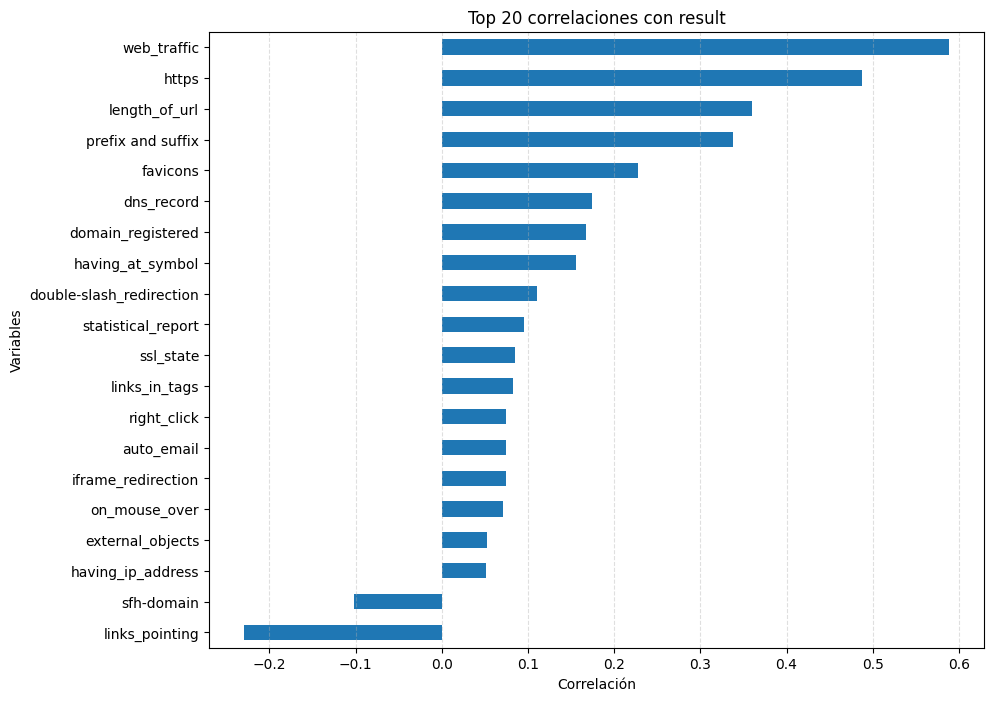

In [9]:
top_n = 20

plt.figure(figsize=(10, 8))
corr_target.head(top_n).sort_values().plot(kind="barh")
plt.title(f"Top {top_n} correlaciones con {TARGET_COL}")
plt.xlabel("Correlación")
plt.ylabel("Variables")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()

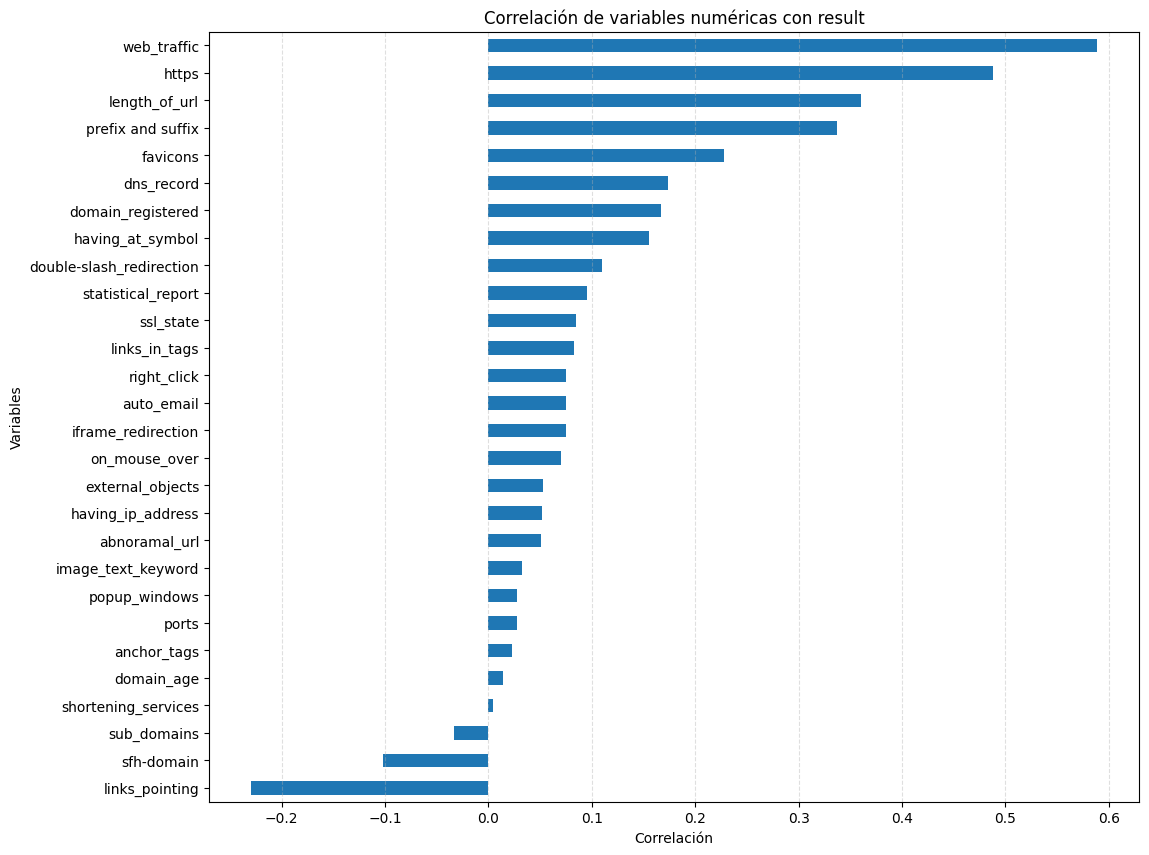

In [10]:
plt.figure(figsize=(12, 10))
corr_target.sort_values().plot(kind="barh")
plt.title(f"Correlación de variables numéricas con {TARGET_COL}")
plt.xlabel("Correlación")
plt.ylabel("Variables")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()

web_traffic                 0.588315
https                       0.487593
length_of_url               0.359927
prefix and suffix           0.337445
links_pointing              0.229277
favicons                    0.227591
dns_record                  0.173904
domain_registered           0.167056
having_at_symbol            0.155328
double-slash_redirection    0.110119
Name: result, dtype: float64


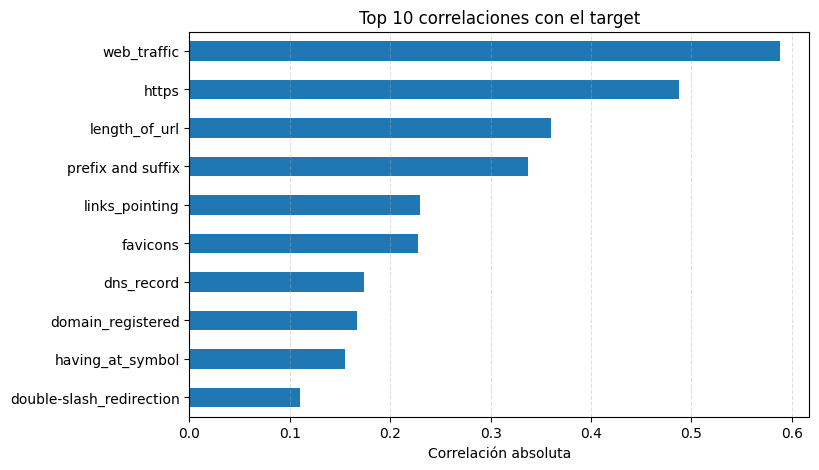

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from app_config import DATA_PATH, TARGET_COL
from ml_toolkit import EDAExplorer

eda = EDAExplorer(DATA_PATH, num=1)
df = eda.df.copy()

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL], errors="coerce")

unique_vals = set(df[TARGET_COL].dropna().unique())
if unique_vals == {-1, 1}:
    df[TARGET_COL] = df[TARGET_COL].map({-1: 0, 1: 1})
elif unique_vals == {0, 1}:
    pass
else:
    raise ValueError(f"Valores inesperados en {TARGET_COL}: {sorted(unique_vals)}")

df[TARGET_COL] = df[TARGET_COL].astype(int)

df = df.drop_duplicates().dropna()

df_num = df.select_dtypes(include=[np.number]).copy()

corr_target = df_num.corr(numeric_only=True)[TARGET_COL].drop(TARGET_COL)
corr_target_abs = corr_target.abs().sort_values(ascending=False)

top10 = corr_target_abs.head(10)
print(top10)

plt.figure(figsize=(8, 5))
top10.sort_values().plot(kind="barh")
plt.xlabel("Correlación absoluta")
plt.title("Top 10 correlaciones con el target")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.show()

In [12]:
import pandas as pd
import numpy as np

from app_config import DATA_PATH, TARGET_COL
from ml_toolkit import EDAExplorer

# Igual que load_eda_data()
eda = EDAExplorer(DATA_PATH, num=1)
df_eda = eda.df.copy()

# Correlación igual que visualizer.py
corr = (
    df_eda.corr(numeric_only=True)[TARGET_COL]
    .drop(TARGET_COL, errors="ignore")
)

corr_abs = corr.abs()

dashboard_corr_df = (
    corr_abs.sort_values(ascending=False)
    .head(10)
    .reset_index()
)

dashboard_corr_df.columns = ["feature", "importance"]

print("Top 10 correlaciones absolutas como en el dashboard:")
display(dashboard_corr_df)

Top 10 correlaciones absolutas como en el dashboard:


,feature,importance
0,web_traffic,0.609129
1,https,0.599569
2,statistical_report,0.315891
3,links_pointing,0.267030
4,dns_record,0.215364
5,domain_registered,0.208262
6,prefix and suffix,0.196345
7,length_of_url,0.189081
8,favicons,0.171924
9,sub_domains,0.162780
